In [5]:
import pandas as pd
pd.set_option('display.max_colwidth', 300)
import warnings 
warnings.filterwarnings('ignore')

# Dataset

In [16]:
df = pd.read_csv("https://raw.githubusercontent.com/eduardofc/data/main/amazon_sports.csv")
df = df[df.stars!=3]
df['good_product'] = (df.stars > 3).astype(int)
df.drop(columns=['review_title', 'product_category', 'stars'], inplace=True)
df.sample(5)

,review_body,good_product
11680,"Como electroestimulador me ha encantado, porque tiene para distintas partes del cuerpo y con diferentes niveles de intensidad. Tiene tres aparatos para ponértelo al mismo tiempo. Calidad precio inmejorable, muy contenta",1
8841,Están bien y Es mejor de lo que esperaba,1
134,"El material interno de la mochila empezó a deshacerse, y ahora no sirve para nada la mochila, te llena todo de goma pegajosa",0
11721,Mi hijo esta encantado con el producto. Dice que va genial y que es super potente. Recomendable 100% si os gusta este deporte,1
2491,Aunque ya se sabe que no es piel de verdad no esta mal el problema es que es muy pequeña. De todas las correas que tengo es la que más justita me queda y tengo una muñeca normal.,0


In [15]:
df.groupby('good_product').size()

good_product
0    4989
1    5372
dtype: int64

# Data preprocessing

In [17]:
X = df.review_body.values
y = df.good_product

In [19]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [20]:
vocab_size = 10000

tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(X)

In [26]:
# tokenizer.index_word

In [23]:
X_tokenized = tokenizer.texts_to_sequences(X)

In [35]:
max_length = 50

X_padded = pad_sequences(X_tokenized, maxlen=max_length, truncating='post')

# Modelo 

In [36]:
import tensorflow.keras as keras

keras.utils.set_random_seed(812)

embed_size = 2

model = keras.Sequential()
model.add(
    keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=embed_size,
        input_length=max_length
    ),
)
model.add(keras.layers.Flatten())
# model.add(keras.layers.Dense(6))
model.add(keras.layers.Dense(1, activation='sigmoid'))

In [38]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 50, 2)             20000     
                                                                 
 flatten (Flatten)           (None, 100)               0         
                                                                 
 dense (Dense)               (None, 1)                 101       
                                                                 
Total params: 20101 (78.52 KB)
Trainable params: 20101 (78.52 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [39]:
model.fit(X_padded, y, epochs=20)

Epoch 1/20


324/324 [==============================] - 1s 2ms/step - loss: 0.6738 - accuracy: 0.5901
Epoch 2/20
324/324 [==============================] - 1s 2ms/step - loss: 0.5350 - accuracy: 0.7770
Epoch 3/20
324/324 [==============================] - 1s 2ms/step - loss: 0.4017 - accuracy: 0.8488
Epoch 4/20
324/324 [==============================] - 1s 2ms/step - loss: 0.3366 - accuracy: 0.8735
Epoch 5/20
324/324 [==============================] - 1s 2ms/step - loss: 0.2956 - accuracy: 0.8884
Epoch 6/20
324/324 [==============================] - 1s 2ms/step - loss: 0.2652 - accuracy: 0.9013
Epoch 7/20
324/324 [==============================] - 1s 2ms/step - loss: 0.2400 - accuracy: 0.9140
Epoch 8/20
324/324 [==============================] - 1s 2ms/step - loss: 0.2193 - accuracy: 0.9220
Epoch 9/20
324/324 [==============================] - 1s 2ms/step - loss: 0.2020 - accuracy: 0.9286
Epoch 10/20
324/324 [==============================] - 1s 2ms/step - loss: 0.1868 - accuracy: 0.93

# Embeddings layer

In [43]:
embd_layer = model.layers[0]

In [46]:
embd_weights = embd_layer.get_weights()[0]

In [48]:
embd_weights.shape

(10000, 2)

In [54]:
for v in ['bueno', 'malo', 'horrible']:
    k = tokenizer.word_index[v]
    print(f"{v}:{k}:{embd_weights[k]}")

bueno:92:[-0.29257601 -0.48060086]
malo:221:[0.2704288  0.24861802]
horrible:1281:[0.7729782 0.6901014]


In [55]:
words = []
x_axis = []
y_axis = []
for k, v in tokenizer.index_word.items():
    x, y = embd_weights[k]
    words.append(v)
    x_axis.append(x)
    y_axis.append(y)
    if k==1500:
        break

In [59]:
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import HoverTool, ColumnDataSource

output_notebook()

source = ColumnDataSource(data=dict(x=x_axis, y=y_axis, words=words))
p = figure(tools="", title="2-dim embeddings space")
p.circle('x','y', size=2, source=source)
hover=HoverTool()
hover.tooltips = [("Palabra", "@words"), ("(x,y)", "($x,$y)")]
p.add_tools(hover)

Loading BokehJS ...

In [60]:
show(p)

# Similitud del coseno

In [61]:
import numpy as np

In [62]:
# (comedia, intriga, terror, thriller, aventuras, sci-fi), n=6

# v_toy_story = np.array([3,1,0,1,5,4])
# v_mission_imp = np.array([2,5,0,5,4,2])
# v_jurassic_park = np.array([1,2,1,3,5,3])
# v_exorcista = np.array([0,4,5,3,1,2])

In [78]:
def dist_cosine(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

In [83]:
# dist_cosine(v_toy_story, v_mission_imp)
# dist_cosine(v_toy_story, v_jurassic_park)
# dist_cosine(v_toy_story, v_exorcista)

In [89]:
for v in ['bueno', 'malo', 'horrible', 'mucho']:
    k = tokenizer.word_index[v]
    print(f"{v}:{k}:{embd_weights[k]}")

bueno:92:[-0.29257601 -0.48060086]
malo:221:[0.2704288  0.24861802]
horrible:1281:[0.7729782 0.6901014]
mucho:41:[-0.21715216  0.06223103]


In [90]:
v_bueno = embd_weights[92]
v_malo = embd_weights[221]
v_horrible = embd_weights[1281]
v_mucho = embd_weights[41]

In [86]:
dist_cosine(v_bueno, v_malo)

-0.9609032

In [87]:
dist_cosine(v_bueno, v_horrible)

-0.9567616

In [88]:
dist_cosine(v_malo, v_horrible)

0.9998936

In [91]:
dist_cosine(v_bueno, v_mucho)

0.26455843

In [93]:
dist_cosine(v_horrible, v_mucho)

-0.5336284

# Word2Vec

In [107]:
reviews = list(df.review_body.values)
reviews[:2]

['Nunca llego el pedido y el vendedor pasa de todo no contestan',
 'No sé como es, porque debería haber llegado ayer día 9 de marzo, y hoy 10 por la noche sigo esperando que llegue el frontal. Y me habéis mandado el formulario de opinión. Pues de momento mala no ha cumplido con la fecha de entrega.']

In [108]:
sentences = []
for rr in reviews:
    ss = rr.split('.')
    for s in ss:
        s = s.strip()
        if len(s)>1:
            s = s.lower()
            s = s.replace("  ", " ")
            sentences.append(s)

In [109]:
sentences[:5]

['nunca llego el pedido y el vendedor pasa de todo no contestan',
 'no sé como es, porque debería haber llegado ayer día 9 de marzo, y hoy 10 por la noche sigo esperando que llegue el frontal',
 'y me habéis mandado el formulario de opinión',
 'pues de momento mala no ha cumplido con la fecha de entrega',
 'guantes cómodos, no lo niego, pero de mala calidad']

In [110]:
word_sentences = [ss.split() for ss in sentences]

In [111]:
word_sentences[0]

['nunca',
 'llego',
 'el',
 'pedido',
 'y',
 'el',
 'vendedor',
 'pasa',
 'de',
 'todo',
 'no',
 'contestan']

In [113]:
from gensim.models import Word2Vec

model = Word2Vec(
    sentences=word_sentences,
    window=3,
    vector_size=20
)

In [114]:
model.wv['bueno']

array([ 0.35985962, -0.28761184,  0.97540504,  0.91632855,  0.20423472,
       -0.13794078,  0.69715774,  1.2478316 , -1.1379267 ,  0.9682247 ,
        1.3819661 , -0.14771448,  0.63824934,  0.6355348 ,  1.3556705 ,
        0.5470776 ,  1.0862892 , -0.02451664, -1.1719812 , -0.6237173 ],
      dtype=float32)

In [119]:
model.wv.most_similar(positive=['buenos'])

[('acabados', 0.9836407899856567),
 ('resistentes', 0.9790917038917542),
 ('cómodos', 0.9784277677536011),
 ('buenas', 0.9690582752227783),
 ('cómodos,', 0.9671388268470764),
 ('comodas', 0.9671000838279724),
 ('bonitos', 0.9668336510658264),
 ('poca', 0.9667914509773254),
 ('estupenda', 0.9663023948669434),
 ('parecen', 0.9656966328620911)]

In [120]:
model.wv.similarity('buenos', 'bonitas')

0.9442577

In [130]:
words1 = [w for w, _ in model.wv.most_similar(positive=['malo'])]
words1 = words1[:4]
words2 = [w for w, _ in model.wv.most_similar(positive=['buenos'])]
words2 = words2[:4]

print(words1)
print(words2)

words = words1 + words2

['justo', 'esperaba,', 'cómodo,', 'fiable,']
['acabados', 'resistentes', 'cómodos', 'buenas']


In [131]:
from sklearn.decomposition import PCA

X = model.wv[words]
pca = PCA(n_components=2)
result = pca.fit_transform(X)

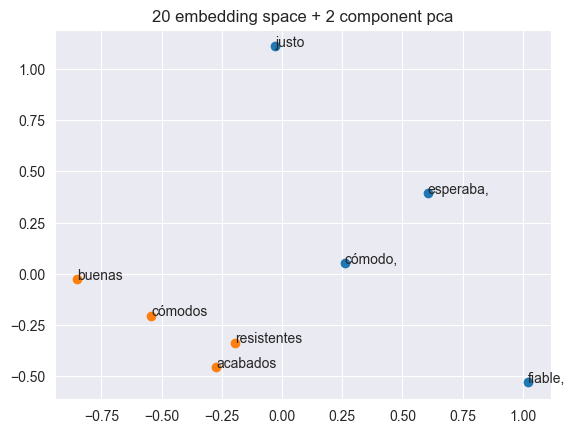

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

plt.scatter(result[:len(words1), 0], result[:len(words1), 1])
plt.scatter(result[len(words1):, 0], result[len(words1):, 1])
for i, w in enumerate(words):
    plt.annotate(w, xy=(result[i, 0], result[i, 1]))
plt.title("20 embedding space + 2 component pca")
plt.show()

# Sentence Transformer

In [133]:
# dataset

df_st = df.sample(2000, replace=False, random_state=99)

reviews = list(df_st.review_body.values)
print(len(reviews))
reviews[:2]

2000


['Lo quería porque trabajo en un club de fútbol y parece una buena herramienta. El problema está que no llegó nunca, y amazon me reembolsó lo pagado.',
 'Por el precio está bien, aunque la calidad es media. Tampoco lo veo tan sólido como para poner mucho peso.']

In [135]:
# model

from sentence_transformers import SentenceTransformer

model = SentenceTransformer("paraphrase-multilingual-mpnet-base-v2")

In [140]:
tt = reviews[0]
len(model.encode(tt))

768

In [141]:
reviews_embeddings = model.encode(reviews, show_progress_bar=True)

Batches: 100%|█████████████████████████████████████████████████████████████████████████| 63/63 [01:01<00:00,  1.03it/s]


In [143]:
print(len(reviews_embeddings))
print(len(reviews_embeddings[55]))

2000
768


In [144]:
# visualizacion

from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    n_iter=500
)

tsne_data = tsne.fit_transform(reviews_embeddings)

In [149]:
df_st[['x','y']] = tsne_data
df_st.head()

,review_body,good_product,x,y
1187,"Lo quería porque trabajo en un club de fútbol y parece una buena herramienta. El problema está que no llegó nunca, y amazon me reembolsó lo pagado.",0,21.291531,-11.696709
8602,"Por el precio está bien, aunque la calidad es media. Tampoco lo veo tan sólido como para poner mucho peso.",1,-11.451897,-5.579478
10734,"La correa encaja perfectamente, viene con todo lo necesario para poder colocarla. Es cuestión de unos pocos minutos. Recomendada. Saludos.",1,-13.928997,3.144215
10822,"Ha sido una buena compra, después de dos semanas de uso. He sentido mucha mejoría, apenas podía caminar, y ahora lo puedo hacer perfectamente. Siempre lo traigo puesto",1,-15.014271,15.479274
8985,"Dan el pego vaya que si, tengo la misma en dos modelos",1,3.295137,9.116229


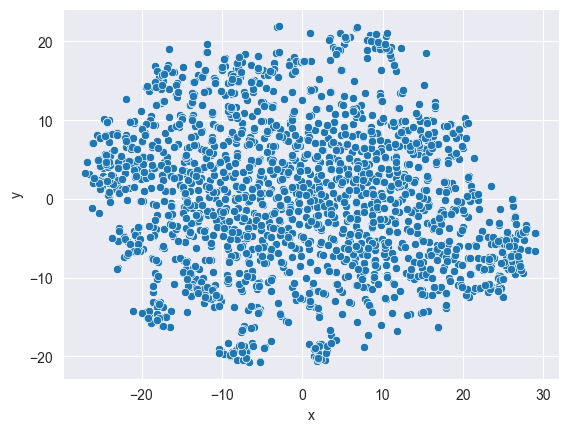

In [150]:
sns.scatterplot(data=df_st, x='x', y='y')
plt.show()

In [152]:
from bokeh.plotting import figure, output_file, show, ColumnDataSource
from bokeh.models import HoverTool
from bokeh.palettes import Viridis256
from bokeh.transform import linear_cmap

source = ColumnDataSource(data={
    "x": df_st['x'],
    "y": df_st['y'],
    "code": df_st['good_product'],
    "post":df_st['review_body']
})

mapper = linear_cmap(
    field_name='code', 
    palette=Viridis256, 
    low=0, high=2
)

p = figure(width=800, height=700, tools="pan,wheel_zoom,box_zoom,reset,hover,save")
p.circle('x', 'y', size=4, source=source, color=mapper, legend_group='code')

hover = p.select_one(HoverTool)
hover.tooltips = [
    ("Post", "@post"),
]

show(p)